# Two Steps MultiFidelity Neural Network

In [47]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3 import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf

In [48]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [49]:
# import of the discretization and diffusion values
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [50]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)

reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [51]:
noise_stddev2 = 0.01       # value?
noise2 = np.random.normal(0, noise_stddev2, U_HF_test.shape[0])
noise_stddev3 = 0.005       # value?
noise3 = np.random.normal(0, noise_stddev3, U_HF_test.shape[0])
U_HF_noise2 = U_HF_test + noise2
U_HF_noise3 = U_HF_test + noise3

noise_stddev4 = 0.02       # value?
noise4 = np.random.normal(0, noise_stddev4, U_HF_test.shape[0])
noise_stddev5 = 0.005       # value?
noise5 = np.random.normal(0, noise_stddev5, U_HF_test.shape[0])
U_HF_noise4 = U_HF_test + noise4
U_HF_noise5 = U_HF_test + noise5



U_HF_test = np.concatenate((U_HF_test, U_HF_noise2,U_HF_noise3,U_HF_noise4,U_HF_noise5),axis=0)


noise_stddev2 = 0.005       # value?
noise2 = np.random.normal(0, noise_stddev2, reaction_HF_test.shape)
noise_stddev3 = 0.003       # value?
noise3 = np.random.normal(0, noise_stddev3, reaction_HF_test.shape)
reaction_HF_noise2 = reaction_HF_test + noise2
reaction_HF_noise3 = reaction_HF_test + noise3

noise_stddev4 = 0.01       # value?
noise4 = np.random.normal(0, noise_stddev4, reaction_HF_test.shape)
noise_stddev5 = 0.003       # value?
noise5 = np.random.normal(0, noise_stddev5, reaction_HF_test.shape)
reaction_HF_noise4 = reaction_HF_test + noise4
reaction_HF_noise5 = reaction_HF_test + noise5

reaction_HF_test = np.concatenate((reaction_HF_test, reaction_HF_noise2,reaction_HF_noise3,reaction_HF_noise4,reaction_HF_noise5))




reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]


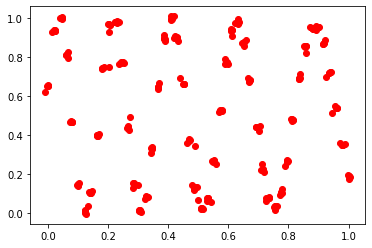

In [52]:

plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")

plt.show()

In [53]:
print(reaction_HF_test.shape)
print(U_HF_test.shape)

n_HF = np.array([100])
Nlf = np.array([200])


(250, 2)
(250,)


In [54]:
U_LF_list = []
U_HF_list = []


NepoLF = 7000  # number of epochs for first NN: NN_LF
NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


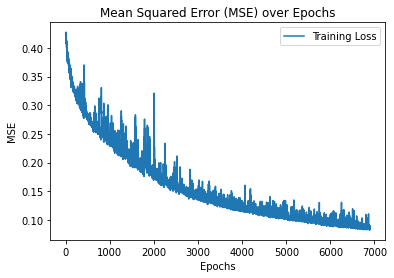

2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.006075658480876802
R^2: 0.9512317194066767
4/4 [==============================] - 0s 0s/step


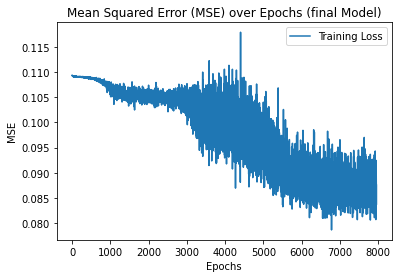

2/2 [==============================] - 0s 0s/step
Elapsed time:  50.38785450000432

HF Model:
Test MSE: 0.09146506654675578
R^2: 0.19199605424445532
11/11 [==============================] - 0s 2ms/step


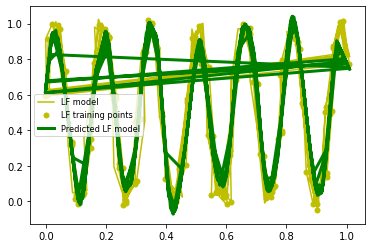

8/8 [==============================] - 0s 0s/step


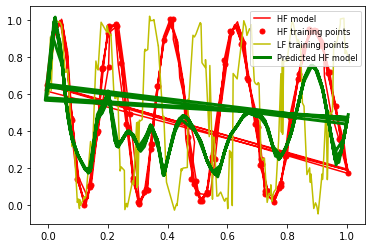

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


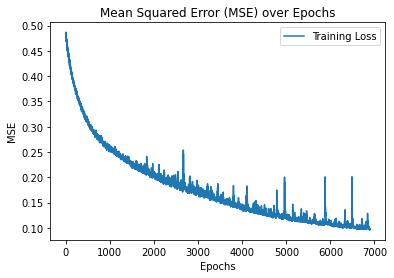

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.014906698774450902
R^2: 0.8689654870272161
4/4 [==============================] - 0s 2ms/step


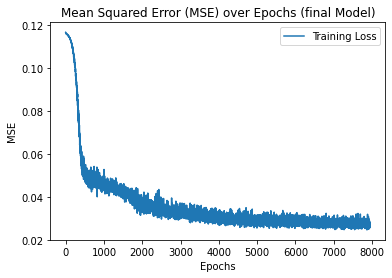

2/2 [==============================] - 0s 10ms/step
Elapsed time:  48.93895199999679

HF Model:
Test MSE: 0.027558897402370254
R^2: 0.7565442339627618
11/11 [==============================] - 0s 2ms/step


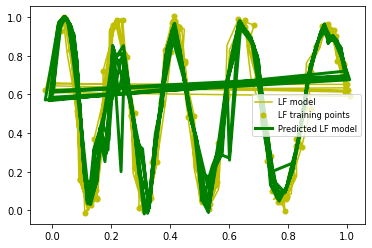

8/8 [==============================] - 0s 1ms/step


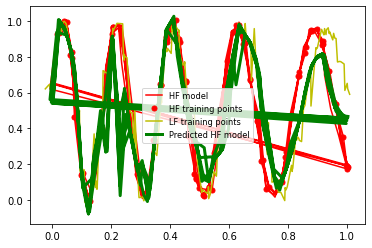

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


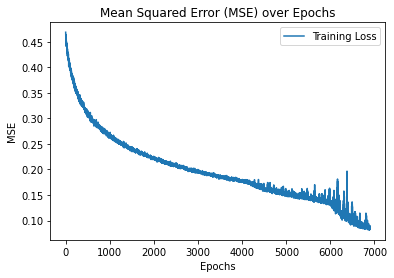

2/2 [==============================] - 0s 12ms/step

LF Model:
Test MSE: 0.005857852731626724
R^2: 0.9502679160537074
4/4 [==============================] - 0s 5ms/step


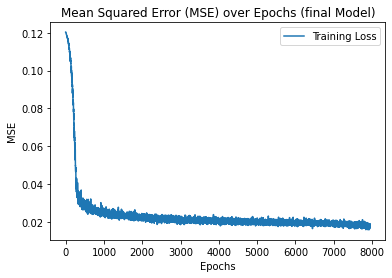

2/2 [==============================] - 0s 0s/step
Elapsed time:  50.489563800016185

HF Model:
Test MSE: 0.01637367848005124
R^2: 0.8553546472122113
11/11 [==============================] - 0s 3ms/step


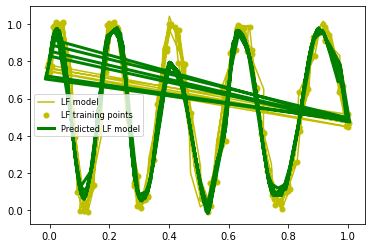

8/8 [==============================] - 0s 2ms/step


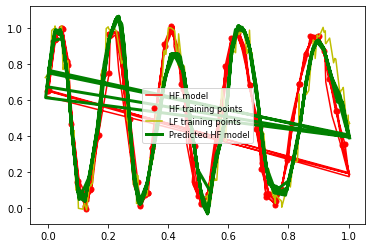

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


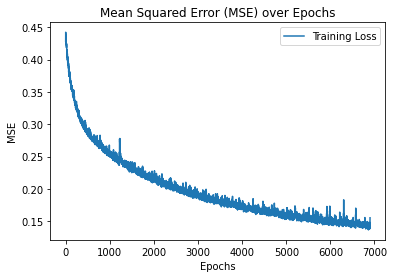

2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.0904210532989096
R^2: 0.21885795933421082
4/4 [==============================] - 0s 5ms/step


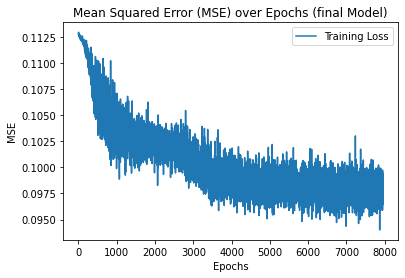

2/2 [==============================] - 0s 0s/step
Elapsed time:  53.43585749997874

HF Model:
Test MSE: 0.08812835853558171
R^2: 0.22147258928294
11/11 [==============================] - 0s 2ms/step


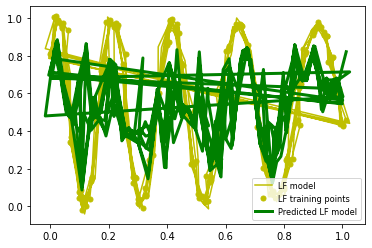

8/8 [==============================] - 0s 2ms/step


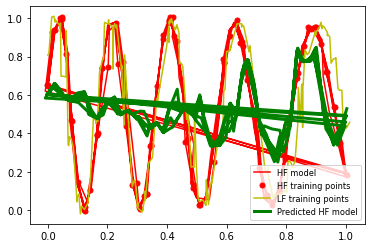

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


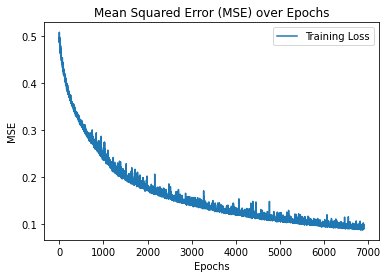

2/2 [==============================] - 0s 5ms/step

LF Model:
Test MSE: 0.02050501276991593
R^2: 0.835473459855124
4/4 [==============================] - 0s 5ms/step


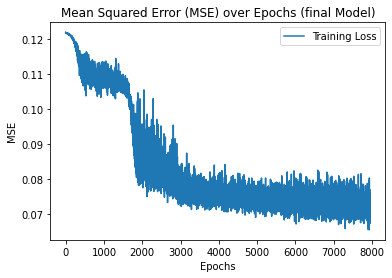

2/2 [==============================] - 0s 18ms/step
Elapsed time:  48.3227497000189

HF Model:
Test MSE: 0.07972971603074425
R^2: 0.2956663393025709
11/11 [==============================] - 0s 2ms/step


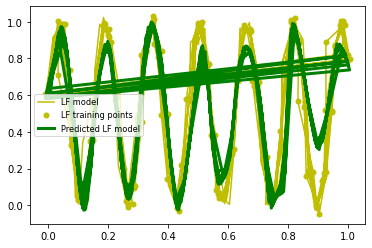

8/8 [==============================] - 0s 2ms/step


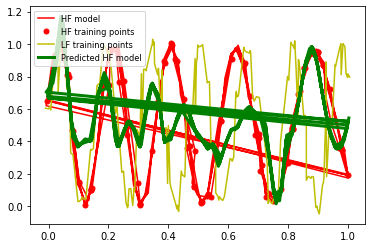

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


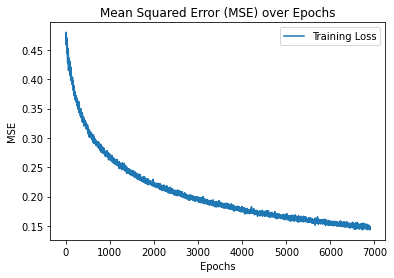

2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.08100383389967913
R^2: 0.28478150080186204
4/4 [==============================] - 0s 0s/step


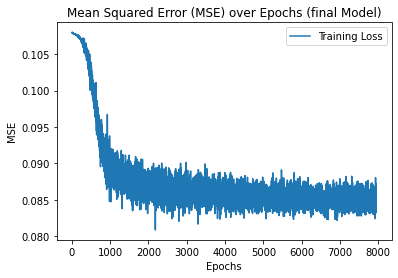

2/2 [==============================] - 0s 5ms/step
Elapsed time:  83.60587270001997

HF Model:
Test MSE: 0.08657935514012248
R^2: 0.23515651149251926
11/11 [==============================] - 0s 3ms/step


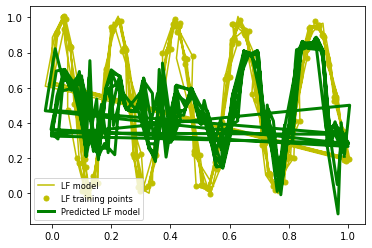

8/8 [==============================] - 0s 2ms/step


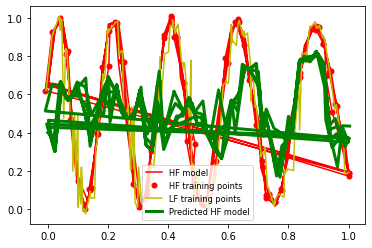

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


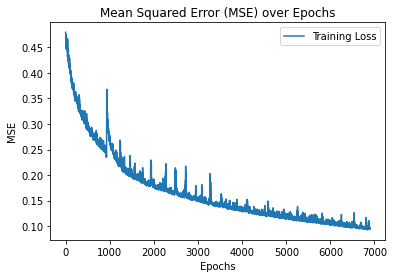

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0027788575391388477
R^2: 0.9763655720961353
4/4 [==============================] - 0s 6ms/step


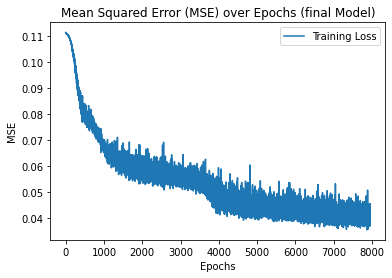

2/2 [==============================] - 0s 0s/step
Elapsed time:  46.69797509998898

HF Model:
Test MSE: 0.030572727898209365
R^2: 0.7299200043588665
11/11 [==============================] - 0s 2ms/step


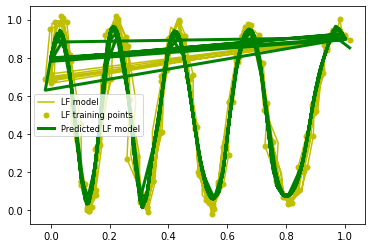

8/8 [==============================] - 0s 2ms/step


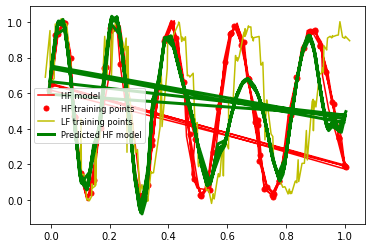

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


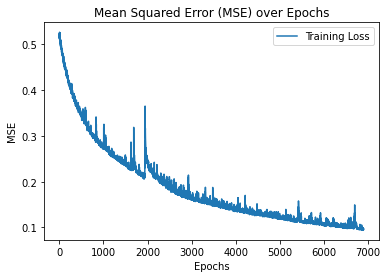

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0025518849182247123
R^2: 0.9784188724667001
4/4 [==============================] - 0s 0s/step


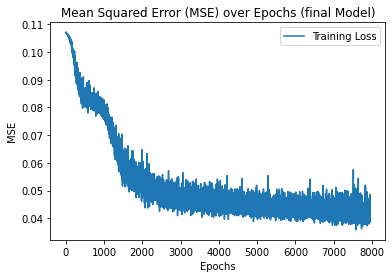

2/2 [==============================] - 0s 0s/step
Elapsed time:  53.94966109999223

HF Model:
Test MSE: 0.0362391479705995
R^2: 0.6798627535454187
11/11 [==============================] - 0s 4ms/step


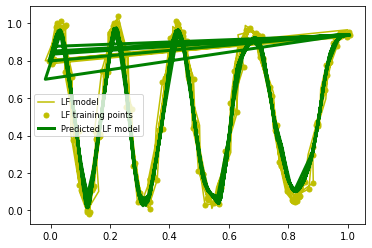

8/8 [==============================] - 0s 4ms/step


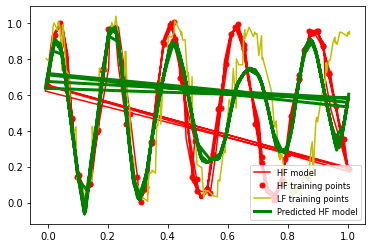

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


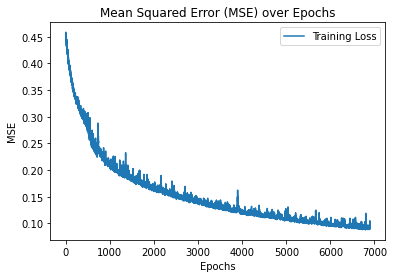

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.013910527479092782
R^2: 0.8884221707322976
4/4 [==============================] - 0s 8ms/step


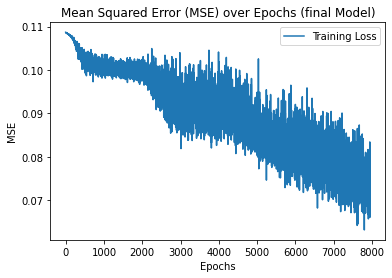

2/2 [==============================] - 0s 0s/step
Elapsed time:  58.403179499990074

HF Model:
Test MSE: 0.06725965189691578
R^2: 0.40582709689418595
11/11 [==============================] - 0s 2ms/step


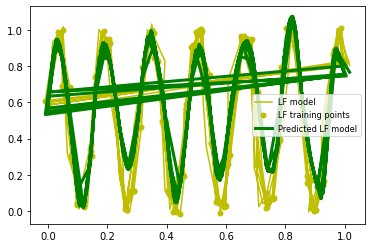

8/8 [==============================] - 0s 1ms/step


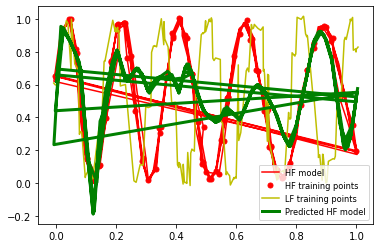

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


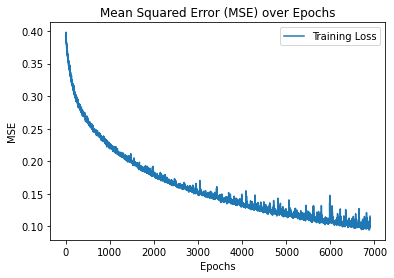

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.06140100062251668
R^2: 0.5064686935870768
4/4 [==============================] - 0s 692us/step


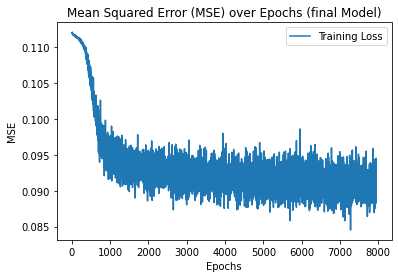

2/2 [==============================] - 0s 3ms/step
Elapsed time:  61.05279289997998

HF Model:
Test MSE: 0.09529854002401363
R^2: 0.15813108467172576
11/11 [==============================] - 0s 2ms/step


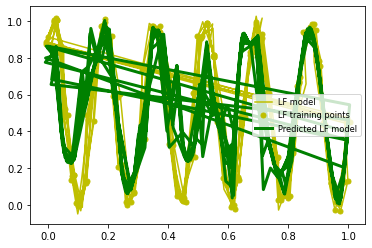

8/8 [==============================] - 0s 3ms/step


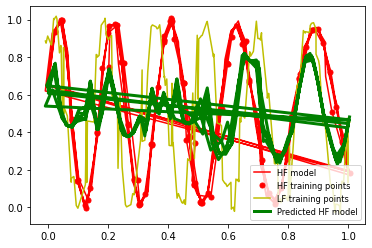

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


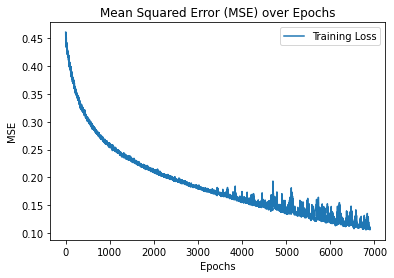

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.04694410859657966
R^2: 0.6320237792737109
4/4 [==============================] - 0s 0s/step


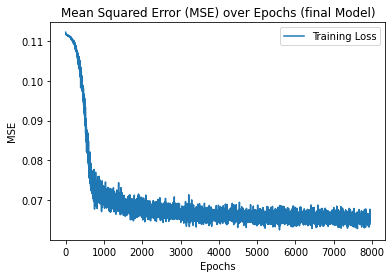

2/2 [==============================] - 0s 6ms/step
Elapsed time:  63.787541099998634

HF Model:
Test MSE: 0.07404321172866653
R^2: 0.3459010145409682
11/11 [==============================] - 0s 845us/step


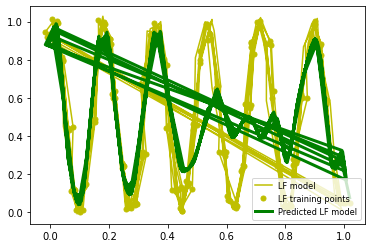

8/8 [==============================] - 0s 3ms/step


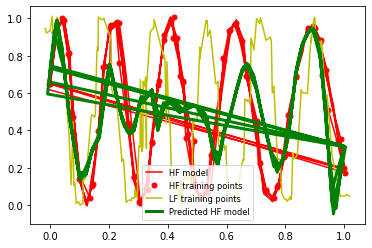

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


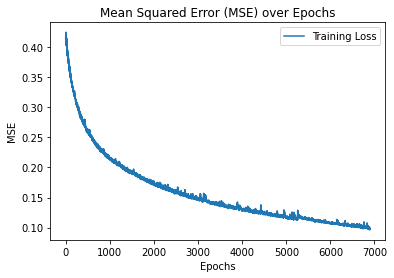

2/2 [==============================] - 0s 6ms/step

LF Model:
Test MSE: 0.039366850176219714
R^2: 0.6759754398954994
4/4 [==============================] - 0s 2ms/step


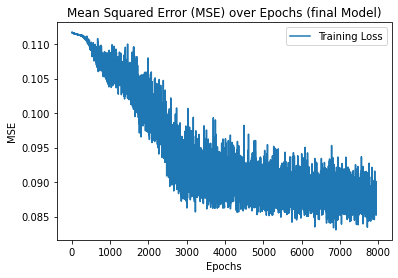

2/2 [==============================] - 0s 0s/step
Elapsed time:  59.532840200001374

HF Model:
Test MSE: 0.09194900825656635
R^2: 0.18772090499014693
11/11 [==============================] - 0s 2ms/step


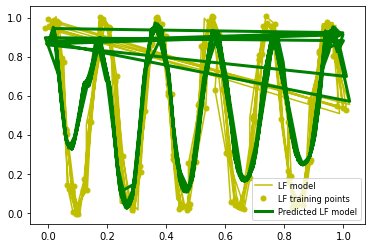

8/8 [==============================] - 0s 6ms/step


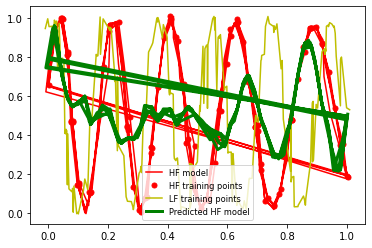

    Discretization  diffusion       R2
0             46.0        0.0  0.19200
1             46.0        5.0  0.75654
2             46.0       75.0  0.85535
3             46.0        1.0  0.22147
4             28.0        0.0  0.29567
5             28.0        5.0  0.23516
6             28.0       75.0  0.72992
7             28.0        1.0  0.67986
8             10.0        0.0  0.40583
9             10.0        5.0  0.15813
10            10.0       75.0  0.34590
11            10.0        1.0  0.18772
    Discretization  diffusion      MSE
0             46.0        0.0  0.09147
1             46.0        5.0  0.02756
2             46.0       75.0  0.01637
3             46.0        1.0  0.08813
4             28.0        0.0  0.07973
5             28.0        5.0  0.08658
6             28.0       75.0  0.03057
7             28.0        1.0  0.03624
8             10.0        0.0  0.06726
9             10.0        5.0  0.09530
10            10.0       75.0  0.07404
11            10.0       

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:301: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:303: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:305: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20684\4142010393.py:307: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

In [55]:
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                permutation = np.random.permutation(len(reaction_HF_test))
                ### IMPORT LF DATASETs
                file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                #print(nhf)

                
                reaction_LF_test = normalization(reaction_LF_test)
                U_LF_test = U_LF_test[
                :,
                - 1,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]        
                U_LF_test = normalization(U_LF_test)
                
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test
                
                # NOISE
                noise_stddev2 = 0.02       # value?
                noise2 = np.random.normal(0, noise_stddev2, U_LF_test.shape)
                noise_stddev3 = 0.01       # value?
                noise3 = np.random.normal(0, noise_stddev3, U_LF_test.shape)
                U_LF_noise2 = U_LF_test + noise2
                U_LF_noise3 = U_LF_test + noise3
                noise_stddev4 = 0.02       # value?
                noise4 = np.random.normal(0, noise_stddev4, U_LF_test.shape)
                noise_stddev5 = 0.01       # value?
                noise5 = np.random.normal(0, noise_stddev5, U_LF_test.shape)
                U_LF_noise4 = U_LF_test + noise4
                U_LF_noise5 = U_LF_test + noise5
                noise_stddev6 = 0.02       # value?
                noise6 = np.random.normal(0, noise_stddev6, U_LF_test.shape)
                U_LF_noise6 = U_LF_test + noise6
                noise_stddev7 = 0.01       # value?
                noise7 = np.random.normal(0, noise_stddev7, U_LF_test.shape)
                U_LF_noise7 = U_LF_test + noise7

                U_LF_test = np.concatenate((U_LF_test, U_LF_noise2,U_LF_noise3,U_LF_noise4,U_LF_noise5,U_LF_noise6,U_LF_noise7),axis=0)

                noise_stddev2 = 0.01       # value?
                noise2 = np.random.normal(0, noise_stddev2, reaction_LF_test.shape)
                noise_stddev3 = 0.005       # value?
                noise3 = np.random.normal(0, noise_stddev3, reaction_LF_test.shape)
                reaction_LF_noise2 = reaction_LF_test + noise2
                reaction_LF_noise3 = reaction_LF_test + noise3
                noise_stddev4 = 0.01       # value?
                noise4 = np.random.normal(0, noise_stddev4, reaction_LF_test.shape)
                noise_stddev5 = 0.005       # value?
                noise5 = np.random.normal(0, noise_stddev5, reaction_LF_test.shape)
                reaction_LF_noise4 = reaction_LF_test + noise4
                reaction_LF_noise5 = reaction_LF_test + noise5
                noise_stddev6 = 0.005       # value?
                noise6 = np.random.normal(0, noise_stddev6, reaction_LF_test.shape)
                reaction_LF_noise6 = reaction_LF_test + noise6
                noise_stddev7 = 0.01       # value?
                noise7 = np.random.normal(0, noise_stddev7, reaction_LF_test.shape)
                reaction_LF_noise7 = reaction_LF_test + noise7

                reaction_LF_test = np.concatenate((reaction_LF_test, reaction_LF_noise2,reaction_LF_noise3,reaction_LF_noise4,reaction_LF_noise5,reaction_LF_noise6,reaction_LF_noise7))
                
                
                
                
                
                # randomization
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )

                test_mse_HF_list = []
                test_mse_LF_list = []

                r2_HF_list = []
                r2_LF_list = []
                
                ##########################       FIRST NN: NN_LF     ##########################
                K.clear_session()
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                
                # reproducibilty porpuse 
                learning_rate = bestLF_params["lr"]
                optimizer_type = bestLF_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                #

                
                modelLF = getModel(bestLF_params, "LF")  # ann_functions
                histLF = modelLF.fit(
                    reaction_LF, U_train_LF,epochs=NepoLF, batch_size=nlf, verbose=0)
                
                plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
                plt.title('Mean Squared Error (MSE) over Epochs')
                plt.xlabel('Epochs')
                plt.ylabel('MSE')
                plt.legend()
                plt.show()

                ULF = modelLF.predict(reaction_LF_test_original)

                U_LF_list.append(ULF)
                print("\nLF Model:")
                
                test_mse = np.mean(np.square(U_LF_test_original - ULF[:, 0]))
                test_mse_LF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r_2 = 1 - np.sum(np.square(U_LF_test_original - ULF[:, 0])) / np.sum(
                    np.square(U_LF_test_original - np.mean(U_LF_test_original))
                )
                r2_LF_list.append(r_2)
                print(f"R^2: {r_2}")
                
                start = perf_counter()
                reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
                reaction_test_in = np.concatenate(
                    (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
                )  # <- TEST INPUT for the second NN: NN_HF

                
                reaction_test_help_original = modelLF.predict(reaction_HF_test_original)[:, 0]
                reaction_test_in_original = np.concatenate(
                    (reaction_HF_test_original, reaction_test_help_original.reshape(-1,1)),axis=1
                )
                
                
                reaction_train_help = modelLF.predict(reaction_HF)[
                    :, 0
                ]  # f_LF(mu_hf_train)
                reaction_final = np.concatenate(
                    (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                name = "2step"
                K.clear_session()
                # best parameters obtained by HPO:

                # best_params = {
                #     "kernel_init": "uniform",
                #     "l2weight": 0.0002588943618918075,
                #     "lr": 0.008365144388542751,
                #     "nodes": 16.0,
                #     "opt": "Adam",
                # }
                best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}
                
                # reproducibilty porpuse 
                learning_rate = best_params["lr"]
                optimizer_type = best_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                #
                
                
                
                finalModel = getModel(
                    best_params, name
                )  # final model chosen according to the best paramters
                hist = finalModel.fit(
                    reaction_final,
                    U_HF,
                    validation_data=(reaction_test_in_original, U_HF_test_original),
                    epochs=NepoHF,
                    batch_size=nhf,
                    verbose=0,
                    validation_freq=20,
                )
                plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
                plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
                plt.xlabel('Epochs')
                plt.ylabel('MSE')
                plt.legend()
                plt.show()

                UHF = finalModel.predict(reaction_test_in_original)
                U_HF_list.append(UHF)

                stop = perf_counter()
                elapsed = stop - start
                print("Elapsed time: ", elapsed)
                print("\nHF Model:")

                test_mse = np.mean(np.square(U_HF_test_original - UHF[:, 0]))
                test_mse_HF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r2_HF = 1 - np.sum(np.square(U_HF_test_original - UHF[:, 0])) / np.sum(
                    np.square(U_HF_test_original - np.mean(U_HF_test_original))
                )
                r2_HF_list.append(r2_HF)
                print(f"R^2: {r2_HF}")
                
                
                plt.figure()
                plt.plot(
                reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
                )
                plt.plot(
                reaction_LF[:, 0],
                U_train_LF,
                "yo",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_LF_test[:, 0],
                modelLF.predict(reaction_LF_test),
                "g-",
                linewidth=3,
                label="Predicted LF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                plt.figure()
                plt.plot(
                reaction_test_in[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
                )
                plt.plot(
                reaction_final[:, 0],
                U_HF,
                "ro",
                markersize=5,
                label="HF training points",
                )
                
                
                order=np.argsort(reaction_LF[:,0])
                
                plt.plot(
                reaction_LF[order,0],
                U_train_LF[order],
                "y-",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_test_in[:, 0],
                finalModel.predict(reaction_test_in),
                "g-",
                linewidth=3,
                label="Predicted HF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()

                #r2_LF_df[[str(Discretizations[m]),diffusion[d]]] = r2_LF_list
                #r2_HF_df[[str(Discretizations[m]),diffusion[d]]] = r2_HF_list
                #mse_LF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_LF_list
                #mse_HF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_HF_list
                
                
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                r2_LF_df=r2_LF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                r2_HF_df=r2_HF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df=mse_LF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df=mse_HF_df.append(new, ignore_index=True)
                
                if len(r2_HF_list[:-1])>0 and r2_HF_list[-1]<max(r2_HF_list[:-1]):
                    save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [57]:
os.makedirs("MF_LF_200_7000_HF_100_8000_2NN_noise_fourier")

r2_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)